**Ahlers et al 2020: Lightkurve reproduction**

This notebook will attempt to reproduce the method of ***Ahlers et al (2020)*** for the named planet below.

Direct references from ***Ahlers et al (2020)*** will be provided with this markup for comparison.

In [1]:
!pip install lightkurve 

In [2]:
def median_filter(lc, window=1.5, photometry='pdcsap'):
    """
    A median filter performed around a datapoint with a
    specified window for lightkurve.LightCurve objects.
    Each point is iteratively divided by the median of
    its corresponding window.

    Parameters
    ----------
    lc : lightkurve.LightCurve object
        A light curve to perform the filtering on.
    window : float, default 1.5
        The length of the filter window in days.
    photometry : string, default 'pdcsap'
        Determines the flux column that will be handled.
        Must be 'pdcsap' or 'sap'.

    Returns
    -------
    lc_filtered : LightCurve object
        The filtered light curve.
    trend : LightCurve object
        A light curve formed by the "moving" median
        of the original lightcurve when detrending.
    """

    # Asserts
    assert photometry in ['pdcsap','sap'], "Photometry must be 'pdcsap' or 'sap'"
    assert window > 0, "Window must have a positive value"

    # Make a light curve copy
    lc_filtered = lc.copy()
    # Get array of flux values
    flux_array = {
        'pdcsap': lc.flux.value,
        'sap'   : lc.sap_flux.value,
    }[photometry]
    # Get array of time values
    time_array = lc.time.value
    # Get array of median flux
    flux_m_array = list()
    # Get number of observations
    n = len(lc)

    # 1. Construct filtered light curve
    # Iterate through all datapoints
    for time in time_array:
        # Get neighbour mask
        neigh_mask = (time_array > time - window/2) &\
                     (time_array < time + window/2)

        # Get neighbour fluxes
        flux_neigh = flux_array[neigh_mask]

        # Obtain the median of the neighbour flux
        flux_m_array.append(np.median(flux_neigh))

    # Then divide all datapoints by their
    # corresponding median of neighbours
    flux_to_correct = {
        'pdcsap': lc_filtered.flux.value,
        'sap'   : lc_filtered.sap_flux.value,
    }[photometry]
    err_to_correct = {
        'pdcsap': lc_filtered.flux_err.value,
        'sap'   : lc_filtered.sap_flux_err.value,
    }[photometry]

    for i in range(n):
        flux_to_correct[i] /= flux_m_array[i]
        err_to_correct[i] /= flux_m_array[i]

    # 2. Construct median trend
    # Copy original lightcurve, keep the flux columns only
    trend = lc.copy()
    trend.keep_columns(['time', 'flux', 'flux_err'])
    trend.flux_err[:] = np.nan
    # https://github.com/lightkurve/lightkurve/issues/1070#issuecomment-844601549
    # Overwrite flux value with the flux_m_array
    trend.flux = flux_m_array

    return lc_filtered, trend


In [3]:
from scipy.stats import sem

def correct_bin_err(binned_lc, origin_lc, new_err='sem', photometry='pdcsap'):
    """
    Correct the flux_error in an binned lightcurve using
    an arbitrary error metric. Requires the binned light
    curve the and intristic light curve.

    Parameters
    ----------
    binned_lc : lightkurve.LightCurve object
        The binned light curve to perform the error
        correction on.
    origin_lc : lightkurve.LightCurve object
        The original light curve that was binned to
        binned_lc.
    new_err : str, default "sem"
        The error metric used to calculate the new flux_err.
        "sem": Standard Error of Mean.
    photometry : string, default 'pdcsap'
        Determines the flux column that will be handled.
        Must be 'pdcsap' or 'sap'.

    Returns
    -------
    output_lc : lightkurve.LightCurve object
        The error-corrected light curve.
    """

    # Asserts
    assert photometry in ['pdcsap','sap'], "Photometry must be 'pdcsap' or 'sap'"
    assert new_err in ['sem'], "new_err must be 'sem'"


    # Get number of bins
    n_bins = len(binned_lc)
    # Copy the binned lightcurve (which to return)
    output_lc = binned_lc.copy()

    # Iterate through bins
    for i in range(n_bins):
        # Get start and end of bin
        bin_start = binned_lc.time_bin_start.value[i]
        bin_size = binned_lc.time_bin_size.value[i] # in days, TODO generalise for any day length
        bin_end = bin_start + bin_size

        # A point belongs to the bin if in the semi-closed
        # interval [bin_start; bin_end)
        # /This is done as bin_ends coincide with next bin_starts/
        # Get all observations from original lightcurve in bin:
        bin_mask = (origin_lc.time.value >= bin_start) & \
                   (origin_lc.time.value < bin_end)

        bin_list = origin_lc[bin_mask]

        # Get fluxes within the bin
        bin_fluxes = {
            'pdcsap': bin_list.flux.value,
            'sap'   : bin_list.sap_flux.value,
        }[photometry]


        # Obtain an 'error' variable that would replace the current bin err

        if (len(bin_list) > 1):

            method = {
                'sem': sem(bin_fluxes),
                # add other error metrics if needed
            }

            error = method[new_err]

            # Replace the value
            error_to_correct = {
                'pdcsap': output_lc.flux_err.value,
                'sap'   : output_lc.sap_flux_err.value,
            }[photometry]

            error_to_correct[i] = error

        else:

            print(i,len((bin_list)))

    return output_lc

In [4]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

In [5]:
print(lk.__version__)

2.5.0


CREATE THE PLANET CLASS FUNCTION

In [6]:
class _planet(object):
    """
    Generic planet class.

    Serves as template for specific planet properties.
    """
    def __init__(self):
        self.name = ''
        self.fullname = ''        # star name
        self.ra = ''              # star RA
        self.dec = ''              # star declination
        self.mag = 0.0             # star V magnitude
        self.primary = 0.0         # primary transit epoch in HJD/BJD
        self.primary_error = 0.0   # primary transit epoch uncertainty in HJD/BJD
        self.period= 0.0           # transit period in days
        self.period_error = 0.0    # transit period uncertainty in days
        self.secondary  = 0.0       # secondary eclipse epoch in HJD/BJD
        self.secondary_error = 0.0 # secondary eclipse epoch uncertainty in HJD/BJD
        self.duration = 0.0        # transit duration in days
        self.duration_error = 0.0  # transit duration uncertainty in days

INSERT YOUR PLANET FOR THE ANALYSIS

In [7]:
class hat_p_70b(_planet): # hat_p_70b example
    """
    HAT-P-70b
    """
    def __init__(self):
        self.name = 'hat-p-70b'
        self.fullname = 'HAT-P-70b'
        self.ra =   '04:58:12.56'
        self.dec = '+09:59:52.73'
        self.mag = 9.47
        #self.primary = 2457095.68572      # primary transit epoch in HJD/BJD
        self.period= 2.744                 # transit period in days
        #self.secondary = 2457094.94516    # secondary eclipse epoch in HJD/BJD
        self.duration = 0.145              # transit duration in days

**LOOK FOR ALL THE DATA ABOUT THE PLANET**

In [8]:
planet = hat_p_70b()

**PRINT PLANET'S NAME TO CHECK**

In [9]:
print(planet.name)

hat-p-70b


**SEARCH FOR ALL THE RESULT OF TESS OBSERVATIONS**

In [10]:
result = lk.search_lightcurve(planet.name, author="SPOC")
display(result)

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 32,2020,SPOC,120,399870368,0.0
1,TESS Sector 98,2025,SPOC,20,399870368,0.0
2,TESS Sector 98,2025,SPOC,120,399870368,0.0


**There are several short-cadence data products. We concatenate the first two sectors and divide them by their common median using the .stitch() method.**

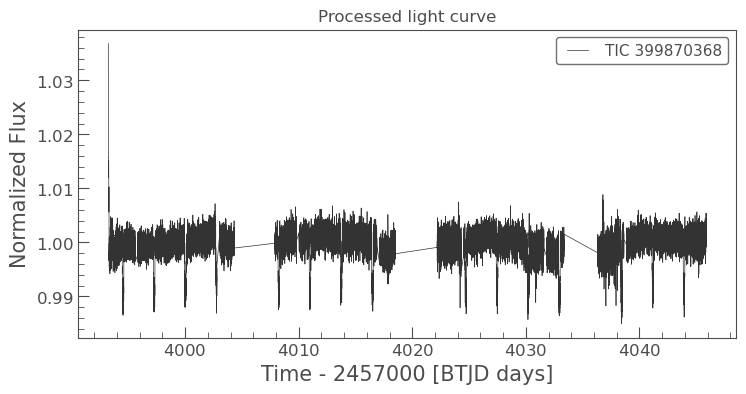

In [24]:
# Obtain and plot light curve collection

# For first two only...
lc_col = result[2].download_all()

# Obtain and plot light curves to be worked with
lc = lc_col.stitch().remove_nans()
lc.plot().set_title("Processed light curve");
plt.show()

**Masking out poor quality data** 
check if any variation in lightcurve is present

Number of poor-quality points excluded:  10


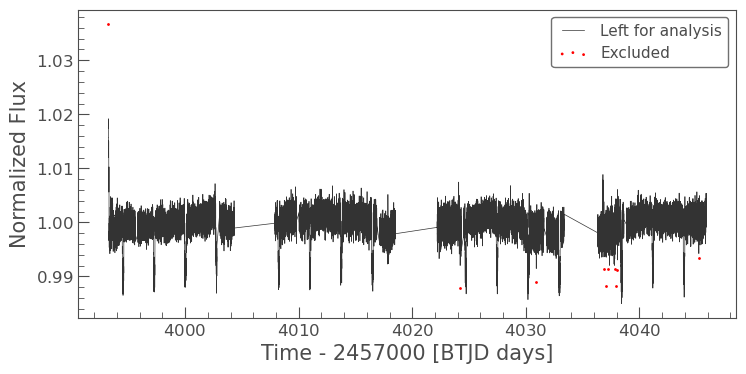

In [25]:
goodquality_mask = (lc.quality.value == 0)
lc_badd = lc[~goodquality_mask]
lc_good = lc[goodquality_mask]

badpoints = np.where(lc.quality.value != 0)
print("Number of poor-quality points excluded: ", len(badpoints[0]))

# Plot "good" and "masked" light curves
ax = lc_good.plot(label="Left for analysis")
lc_badd.scatter(ax=ax, label="Excluded", color='r')
plt.show(ax)

**Mask out weird segments / poor data between sections**

... take care: this needs customising for each new stitched light curve collection.

It might be easier to do this by plotting short sections in turn, to check data integrity.

This could be done by looping over a pre-defined range plus n_epoch*periods, and inspecting the data

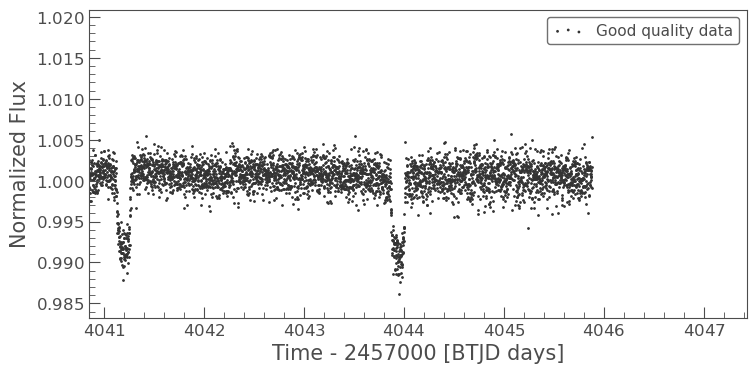

In [52]:
ax = lc_good.scatter(label="Good quality data")

# first transit in this sector
t_first_transit = 3990

# which epoch to plot?
epoch = 19
ref_transit = t_first_transit + epoch*planet.period

pre_transit_range = +1.0
post_transit_range = +5.0

#set the range
p1 = ref_transit - 2.0*planet.duration - pre_transit_range
p2 = ref_transit + 2.0*planet.duration + post_transit_range
ax.set_xlim(p1,p2)

plt.show(ax)

**DEFINE THE EXCLUSION MASKS**

Here needs modification each time


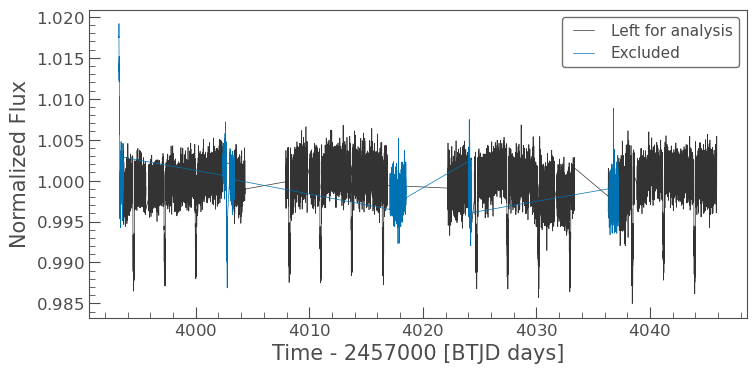

In [53]:
# Define time domain of the exclusion mask

# Setting time ranges for exclusion, eg:
# less than some value: ((lc.time.value < 2284.0))
# greater than some value: ((lc.time.value > 2300.0))
#
# between 2 values: ((lc.time.value > 2285.0) & (lc.time.value < 2287.0))
#
# and combine all these with | (= "or")

#define the mask
exclusion_mask = (lc_good.time.value < 2174.4) |\
                 ((lc_good.time.value > 2200.1) & (lc_good.time.value < 2200.3)) |\
                 ((lc_good.time.value > 3993.0) & (lc_good.time.value < 3993.6)) |\
                 ((lc_good.time.value > 4002.4) & (lc_good.time.value < 4003.4)) |\
                 ((lc_good.time.value > 4017.0) & (lc_good.time.value < 4019.0)) |\
                 ((lc_good.time.value > 4024.0) & (lc_good.time.value < 4024.3)) |\
                 ((lc_good.time.value > 4036.4) & (lc_good.time.value < 4037.2))
#exclusion_mask = ((lc_good.time.value > 1720.6) & (lc_good.time.value < 1725.1)) | \
                 #(lc_good.time.value > 1734.4)



# Get "clean" and "exclusion" light curves
# OR FOR NO EXCLUSIONS: JUST MAKE A COPY OF THE ORIGINAL LC ARRAY OF VALUES
#lc_clean = lc_good.copy()
lc_clean = lc_good[~exclusion_mask]
lc_exclude = lc_good[exclusion_mask]

# Plot "clean" and "exclusion" light curves
ax = lc_clean.plot(label="Left for analysis")
lc_exclude.plot(ax=ax, label="Excluded")
plt.show(ax)

In [54]:
print(exclusion_mask)

[ True  True  True ... False False False]


**MEDIAN FILTER TREND**

to remove slow variations on timescale much longer than transits



Plot the data with the median trend, and with the trend removed

In [55]:
# Set the smoothing window - default is 36 hours
win_hours = 36.0
win_days = win_hours/24.0

# get the median trend and its division into the data (= "filtered")
lc_filtered, trend = median_filter(lc_clean, window=win_days)

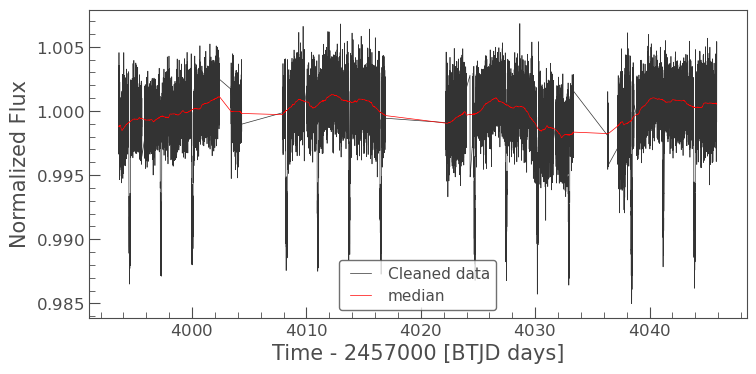

In [56]:
ax = lc_clean.plot(label="Cleaned data")
#overplot the median trend in red
trend.plot(ax=ax, label="median",c='r')
plt.show(ax)

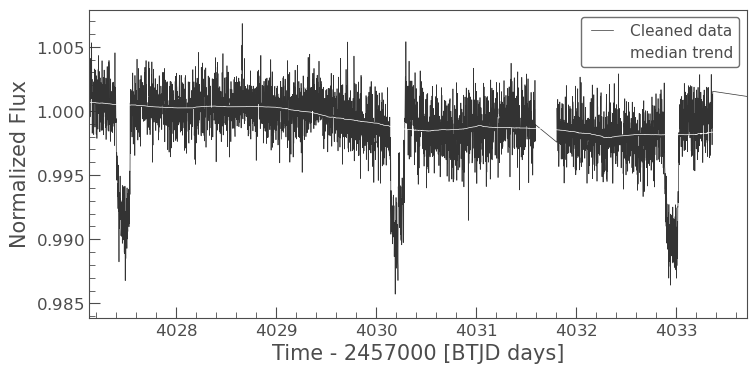

In [62]:
ax = lc_clean.plot(label="Cleaned data")
#overplot the median trend in white
trend.plot(ax=ax, label="median trend",c='w')

# first transit in this sector
t_first_transit = 3990
# which epoch to plot?
epoch = 14
ref_transit = t_first_transit + epoch*planet.period

pre_transit_range = +1.0
post_transit_range = +5.0

#set the range
p1 = ref_transit - 2.0*planet.duration - pre_transit_range
p2 = ref_transit + 2.0*planet.duration + post_transit_range
ax.set_xlim(p1,p2)

plt.show(ax)

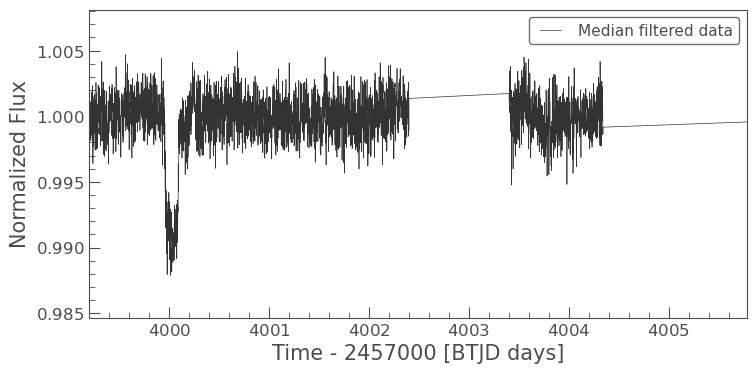

In [65]:
ax = lc_filtered.plot(label="Median filtered data")

# first transit in this sector
t_first_transit = 3995
# which epoch to plot?
epoch = 2
ref_transit = t_first_transit + epoch*planet.period

pre_transit_range = +1.0
post_transit_range = +5.0

#set the range
p1 = ref_transit - 2.0*planet.duration - pre_transit_range
p2 = ref_transit + 2.0*planet.duration + post_transit_range
ax.set_xlim(p1,p2)

plt.show(ax)

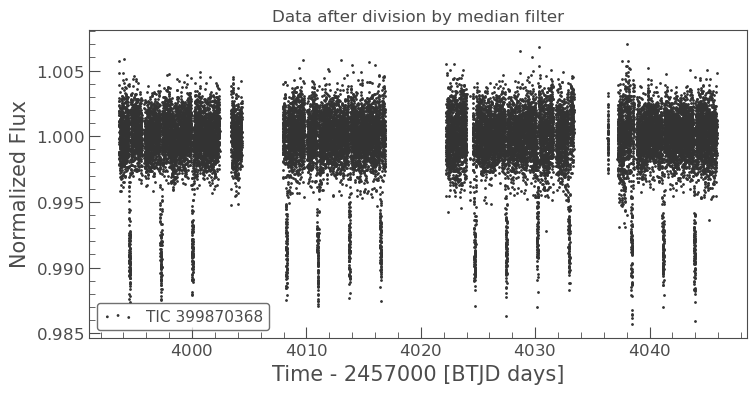

In [66]:
lc_filtered.scatter().set_title("Data after division by median filter");
plt.show()

**FOLDING THE LIGHT CURVES**

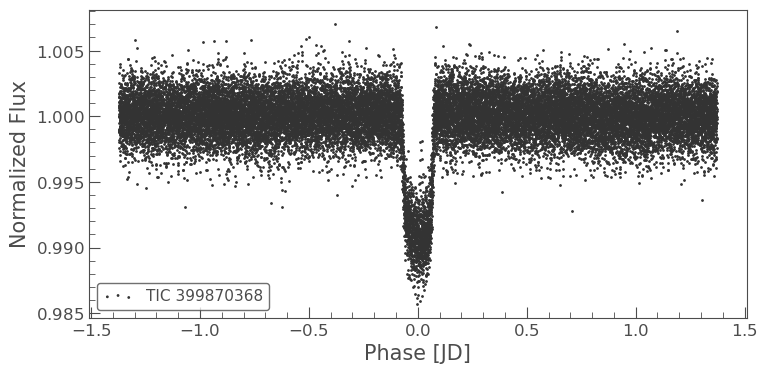

In [74]:
# Period from published value
# Set the phase offset here - approximate for the moment; we can get an accurate phase from a simple model fit
# Start with 0.0, and then read off the plot and SUBTRACT the phase you see
#phase_offset = -0.08824334
primary_min = 0.94
phase_offset = -primary_min

lc_fold = lc_filtered.fold(period=planet.period,epoch_phase=phase_offset)

# Plot light curve
lc_fold.scatter()
plt.show(ax)

In [75]:
display(lc_fold)

time,flux,flux_err,time_original,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,,,,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
TimeDelta,float32,float32,Time,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
-1.3718553499334782,1.0011216e+00,7.7069172e-04,4026.096692825107,5.4215393e-03,2015018,172.13576,1180.51170,2.6695881e+04,1.8878389e+01,1.9957217e+03,5.2843919e+00,3.0433701e+04,2.3428722e+01,0,———,———,———,———,172.13576,4.5935917e-04,1180.51170,5.9318170e-04,6.5385565e-02,-6.1309215e-02
-1.3717478777743712,9.9801749e-01,7.7764364e-04,4001.400800297266,5.3506782e-03,1997237,172.09682,1180.67297,2.7298660e+04,1.9046232e+01,1.9589060e+03,5.2448812e+00,3.0335439e+04,2.3637022e+01,0,———,———,———,———,172.09682,4.6300283e-04,1180.67297,5.7506177e-04,4.3097883e-02,1.2843743e-01
-1.3716804015630288,9.9880463e-01,7.8142382e-04,4009.6328677734773,5.4776534e-03,2003164,172.09811,1180.66815,2.7285686e+04,1.9142111e+01,2.1502002e+03,5.4048777e+00,3.0364588e+04,2.3756010e+01,0,———,———,———,———,172.09811,4.6584412e-04,1180.66815,5.7923369e-04,4.5959152e-02,1.2340774e-01
-1.3714594433553562,1.0008438e+00,7.6921360e-04,4028.841088731685,5.3742649e-03,2016994,172.13922,1180.49165,2.6574156e+04,1.8834070e+01,1.9711218e+03,5.2633748e+00,3.0412156e+04,2.3373722e+01,0,———,———,———,———,172.13922,4.5908109e-04,1180.49165,5.9621339e-04,6.5283045e-02,-8.5570522e-02
-1.3714313389616923,1.0010903e+00,7.6640869e-04,4039.8171168360786,5.0185309e-03,2024897,172.16307,1180.41203,2.6474441e+04,1.8771828e+01,1.9414612e+03,5.2248673e+00,3.0430080e+04,2.3296476e+01,0,———,———,———,———,172.16307,4.5476106e-04,1180.41203,5.9863651e-04,9.3582086e-02,-1.7596313e-01
-1.371416762070825,9.9757743e-01,7.8323559e-04,3995.9131314129695,5.1792669e-03,1993286,172.09676,1180.72217,2.7722662e+04,1.9157669e+01,1.9258274e+03,5.2119055e+00,3.0281721e+04,2.3775318e+01,0,———,———,———,———,172.09676,4.6136731e-04,1180.72217,5.6568283e-04,6.3131914e-02,1.9074254e-01
-1.3712537426384324,1.0004991e+00,8.5607107e-04,4004.145294432402,5.4016868e-03,1999213,172.08761,1180.67774,2.7235250e+04,2.0953260e+01,5.7222412e+03,7.8781610e+00,3.0390805e+04,2.6003710e+01,0,———,———,———,———,172.08761,5.2505807e-04,1180.67774,6.4430613e-04,2.9579194e-02,1.3301341e-01
-1.371208763469757,1.0025011e+00,7.7668944e-04,4012.3773394115706,5.5061313e-03,2005140,172.11391,1180.61220,2.7147119e+04,1.9034687e+01,2.0212644e+03,5.3086753e+00,3.0490664e+04,2.3622694e+01,0,———,———,———,———,172.11391,4.6133960e-04,1180.61220,5.8263319e-04,5.4554347e-02,5.8357533e-02


In [76]:
# Set a small median smooth window - 0.01 days is 864 seconds (about 15 mins)
medwin = 0.01
_,trend = median_filter (lc_fold, medwin)

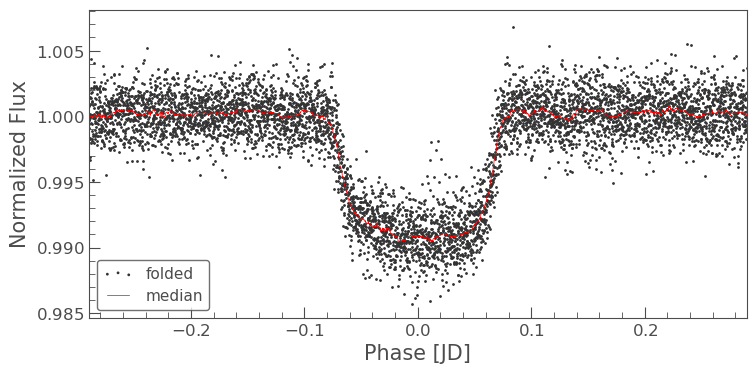

In [77]:
# Plot folded light curve data with median-smoothed curve around zero phase
ax = lc_fold.scatter(label="folded")

#set the range
p1 = - 2.0*planet.duration
p2 = + 2.0*planet.duration
ax.set_xlim(p1,p2)

trend.plot(ax=ax, label="median",c='r')
plt.show(ax)

In [78]:
print(lc_fold[0])

        time             flux         flux_err      time_original      timecorr    cadenceno  centroid_col centroid_row    sap_flux     sap_flux_err     sap_bkg      sap_bkg_err    pdcsap_flux   pdcsap_flux_err     quality      psf_centr1 psf_centr1_err psf_centr2 psf_centr2_err mom_centr1 mom_centr1_err mom_centr2 mom_centr2_err   pos_corr1      pos_corr2   
                                                                          d                       pix          pix       electron / s   electron / s   electron / s   electron / s   electron / s    electron / s                      pix          pix          pix          pix          pix          pix          pix          pix            pix            pix      
------------------- -------------- -------------- ----------------- -------------- ---------- ------------ ------------ -------------- -------------- -------------- -------------- -------------- --------------- ---------------- ---------- -------------- ---------- -----------

**Binning - and recalculate error bar from scatter in each (folded) bin**

In [79]:
# Re-bin at 120 seconds
# 2024 Feb 23 -- you must set the bin size here in days, and then make sure
# this is reflected in the function correct_bin_err, to avoid weird output there
#
# The time bin is now in days (in lightkurve v2)

bin_secs = 120.0
bin_size = bin_secs/3600.0/24.0 # in days
lc_bin = lc_fold.bin(time_bin_size=bin_size, aggregate_func=np.mean)

#check the bin_size time value if needed
#print(lc_bin.time_bin_size.value[0])

# Correct bin errors
lc_final = correct_bin_err(lc_bin, lc_fold)

# Plot light curve with errorbars
lc_final.errorbar()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

**Let's zoom in a bit, with the median-smoothed trend overlaid - set the limits**

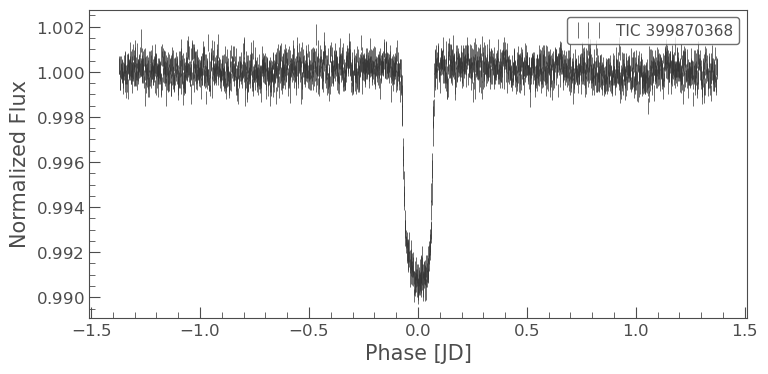

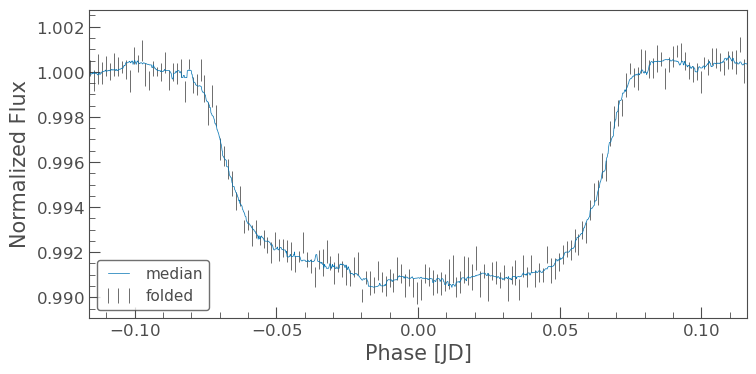

In [80]:
# Plot light curve with errorbars
ax = lc_final.errorbar(label="folded")
trend.plot(ax=ax, label="median")

#set the range
xscale = 0.8
p1 = -1.0*xscale*planet.duration
p2 = +1.0*xscale*planet.duration
ax.set_xlim(p1,p2)

plt.show(ax)

**Prepare CSV files for Exobush fitting**

We export three-column CSV files in the order: time (or phase), flux, flux_err for Exobush fitting.




In [81]:
from astropy.io import ascii

# Prepare for output
lc_final.keep_columns(['time','flux','flux_err'])

# Convert the x-axis to true orbital phase (not days) = time/period
lc_final_orbit_phase = lc_final.copy()
time_arr = lc_final_orbit_phase.time.value
lc_final_orbit_phase.time = time_arr / planet.period


# Plot light curves
lc_final.scatter()
lc_final_orbit_phase.scatter().set_xlabel("Phase")

# Export light curves.
csv_name = planet.name+".csv"
dat_name = planet.name+".dat"
csv_phase_name = planet.name+"_phase.csv"
dat_phase_name = planet.name+"_phase.dat"
#
ascii.write(
    lc_final,
    csv_name,
    format='csv',
    fast_writer=False,
    overwrite=True
)
ascii.write(
    lc_final,
    dat_name,
    format='no_header',
    delimiter=" ",
    fast_writer=False,
    overwrite=True
)

ascii.write(
    lc_final_orbit_phase,
    csv_phase_name,
    format='csv',
    fast_writer=False,
    overwrite=True
)
ascii.write(
    lc_final_orbit_phase,
    dat_phase_name,
    format='no_header',
    delimiter=" ",
    fast_writer=False,
    overwrite=True
)


In [82]:
# Display the data structure (just to check)
display(lc_final_orbit_phase)

time,flux,flux_err
,,
TimeDelta,float64,float64
-0.49969420753973526,1.000267744064331,0.00035487080533814775
-0.4991880526968458,1.0003001689910889,0.00041458753807628357
-0.4986818978539562,1.0002343654632568,0.0004753689321074171
-0.49817574301106676,0.9996229410171509,0.00043866718149881756
-0.49766958816817713,0.9994363784790039,0.0002601654923863208
-0.4971634333252877,1.0000699758529663,0.0003324140498709418
-0.49665727848239805,1.0003811120986938,0.00030220277428167383
-0.49615112363950853,1.000016212463379,0.00032157774727384705


In [83]:
#Zoom in and replot

#set limits here - in orbit phase
p1 = -0.1
p2 = +0.1

#ax = lc_final_orbit_phase.scatter()
ax = lc_final_orbit_phase.errorbar()
ax.set_xlabel("Phase")
ax.set_xlim(p1,p2)

(-0.1, 0.1)